In [1]:
!pip install mlcroissant
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.1 MB/s eta 0:00:00
  Created wheel for jsonpath-rw: filename=jsonpath_rw-1.4.0-py3-none-any.whl size=15127 sha256=f69bf4e03c50b143ae1e1dc26760b14f87f3495fd995ce6fedd2b1b98c75212e
  Stored in directory: /root/.cache/pip/wheels/e5/8d/50/ee73263c97069bd6040ff40633d444fefaac7beff73abe81a7
Successfully built jsonpath-rw
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fet

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

In [3]:
# matplotlib 폰트설정:
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path).get_name()
mpl.rc('font', family=font_prop)
plt.rcParams['axes.unicode_minus'] = False
fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic')
print("현재 설정된 폰트:", mpl.rcParams['font.family'])

현재 설정된 폰트: ['NanumGothic']


# 1. 설문 결과를 모델용 요약 데이터로 만들기

기본 라이브러리 및 폴더 설정

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("기본 설정 완료")

기본 설정 완료


CSV 파일 업로드
*   student_profile.csv
*   student_error_sequence.csv

In [5]:
from google.colab import files

uploaded = files.upload()

Saving student_profile.csv to student_profile.csv
Saving student_error_sequence.csv to student_error_sequence.csv


CSV 파일 불러오기

In [6]:
profile_df = pd.read_csv("student_profile.csv", encoding="utf-8-sig")
seq_df = pd.read_csv("student_error_sequence.csv", encoding="utf-8-sig")

print("student_profile.csv 크기:", profile_df.shape)
print("student_error_sequence.csv 크기:", seq_df.shape)

display(profile_df.head())
display(seq_df.head())

student_profile.csv 크기: (20, 5)
student_error_sequence.csv 크기: (60, 4)


,student_id,weak_topic,error_type,material_preference,difficulty_level
0,S01,함수,Strategy,예제,중
1,S02,함수,Process,영상,중
2,S03,함수,Process,시각자료,중
3,S04,함수,Strategy,예제,중
4,S05,함수,Macro,개념정리,중


,student_id,step,error_type,topic
0,S01,1,Process,함수
1,S01,2,Strategy,함수
2,S01,3,Micro,함수
3,S02,1,Macro,함수
4,S02,2,Process,함수


데이터 열 이름 확인

In [7]:
print("student_profile columns:")
print(profile_df.columns.tolist())

print("\nstudent_error_sequence columns:")
print(seq_df.columns.tolist())

student_profile columns:
['student_id', 'weak_topic', 'error_type', 'material_preference', 'difficulty_level']

student_error_sequence columns:
['student_id', 'step', 'error_type', 'topic']


데이터 기본 분포 확인

In [8]:
print("오류 유형 분포")
display(profile_df["error_type"].value_counts())

print("취약 단원 분포")
display(profile_df["weak_topic"].value_counts())

print("선호 자료 형태 분포")
display(profile_df["material_preference"].value_counts())

print("난이도 분포")
display(profile_df["difficulty_level"].value_counts())

오류 유형 분포


,count
error_type,
Strategy,7
Process,6
Macro,4
Micro,3


취약 단원 분포


,count
weak_topic,
함수,12
방정식,3
도형,3
확률과통계,2


선호 자료 형태 분포


,count
material_preference,
예제,5
영상,5
시각자료,4
개념정리,3
문제풀이,3


난이도 분포


,count
difficulty_level,
중,14
하,4
상,2


오류 유형 분포 그래프

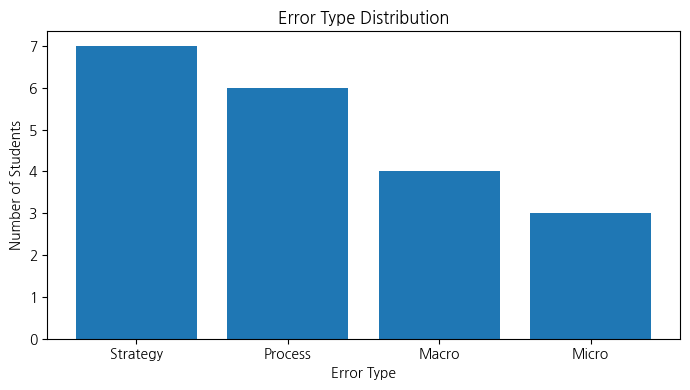

In [9]:
error_counts = profile_df["error_type"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(error_counts.index, error_counts.values)
plt.xlabel("Error Type")
plt.ylabel("Number of Students")
plt.title("Error Type Distribution")
plt.tight_layout()
plt.savefig("figures/error_type_distribution.png", dpi=200)
plt.show()

취약 단원 분포 그래프

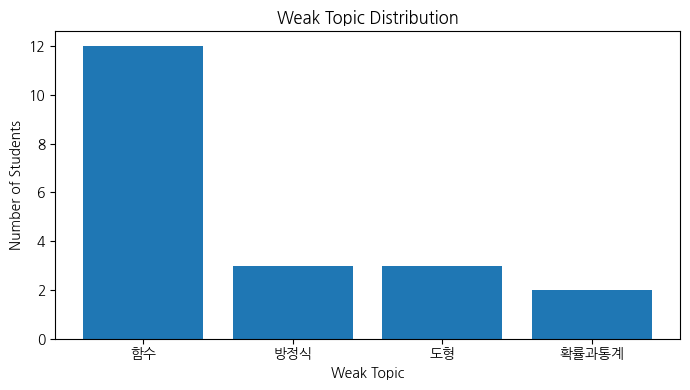

In [10]:
topic_counts = profile_df["weak_topic"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(topic_counts.index, topic_counts.values)
plt.xlabel("Weak Topic")
plt.ylabel("Number of Students")
plt.title("Weak Topic Distribution")
plt.tight_layout()
plt.savefig("figures/weak_topic_distribution.png", dpi=200)
plt.show()

규칙 기반 추천 함수 만들기

In [11]:
def recommend_from_profile(row):
    error_type = row["error_type"]
    weak_topic = row["weak_topic"]
    material_preference = row["material_preference"]

    recommendations = []

    # 1. 오류 유형별 추천
    if error_type == "Macro":
        recommendations.append("쉬운 개념 설명 자료")
    elif error_type == "Micro":
        recommendations.append("계산 실수 체크리스트")
    elif error_type == "Process":
        recommendations.append("문제 접근 순서 카드")
    elif error_type == "Strategy":
        recommendations.append("풀이 전략 가이드")

    # 2. 취약 단원별 추천
    if weak_topic == "함수":
        recommendations.append("함수 그래프 시각화 자료")
    elif weak_topic == "방정식":
        recommendations.append("방정식 풀이 단계 자료")
    elif weak_topic == "도형":
        recommendations.append("도형 개념 시각화 자료")
    elif weak_topic == "확률과통계":
        recommendations.append("확률 개념 예시 자료")
    else:
        recommendations.append("기본 개념 복습 자료")

    # 3. 선호 자료 형태 반영
    if material_preference == "영상":
        recommendations.append("짧은 설명 영상")
    elif material_preference == "시각자료":
        recommendations.append("한 장 요약 이미지")
    elif material_preference == "예제":
        recommendations.append("예제 중심 자료")
    elif material_preference == "개념정리":
        recommendations.append("개념 정리 자료")
    elif material_preference == "문제풀이":
        recommendations.append("문제 풀이 자료")

    return " + ".join(recommendations)

학생별 추천 결과 만들기

In [12]:
profile_df["recommended_material"] = profile_df.apply(recommend_from_profile, axis=1)

display(
    profile_df[
        ["student_id", "weak_topic", "error_type", "material_preference", "recommended_material"]
    ].head(10)
)

,student_id,weak_topic,error_type,material_preference,recommended_material
0,S01,함수,Strategy,예제,풀이 전략 가이드 + 함수 그래프 시각화 자료 + 예제 중심 자료
1,S02,함수,Process,영상,문제 접근 순서 카드 + 함수 그래프 시각화 자료 + 짧은 설명 영상
2,S03,함수,Process,시각자료,문제 접근 순서 카드 + 함수 그래프 시각화 자료 + 한 장 요약 이미지
3,S04,함수,Strategy,예제,풀이 전략 가이드 + 함수 그래프 시각화 자료 + 예제 중심 자료
4,S05,함수,Macro,개념정리,쉬운 개념 설명 자료 + 함수 그래프 시각화 자료 + 개념 정리 자료
5,S06,방정식,Micro,문제풀이,계산 실수 체크리스트 + 방정식 풀이 단계 자료 + 문제 풀이 자료
6,S07,함수,Process,영상,문제 접근 순서 카드 + 함수 그래프 시각화 자료 + 짧은 설명 영상
7,S08,도형,Strategy,예제,풀이 전략 가이드 + 도형 개념 시각화 자료 + 예제 중심 자료
8,S09,확률과통계,Macro,개념정리,쉬운 개념 설명 자료 + 확률 개념 예시 자료 + 개념 정리 자료
9,S10,함수,Strategy,시각자료,풀이 전략 가이드 + 함수 그래프 시각화 자료 + 한 장 요약 이미지


추천 결과 저장

In [13]:
profile_df.to_csv(
    "data/student_profile_with_recommendation.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료: data/student_profile_with_recommendation.csv")

저장 완료: data/student_profile_with_recommendation.csv


# 2. Baseline Random Forest 모델

추천 그룹 만들기

In [14]:
def make_recommendation_group(error_type):
    if error_type == "Macro":
        return "개념 이해 보완"
    elif error_type == "Micro":
        return "계산 실수 점검"
    elif error_type == "Process":
        return "문제 접근 순서"
    elif error_type == "Strategy":
        return "풀이 전략 선택"
    else:
        return "기본 복습"

profile_df["recommendation_group"] = profile_df["error_type"].apply(make_recommendation_group)

display(
    profile_df[
        ["student_id", "weak_topic", "error_type", "material_preference", "recommendation_group"]
    ].head(10)
)

,student_id,weak_topic,error_type,material_preference,recommendation_group
0,S01,함수,Strategy,예제,풀이 전략 선택
1,S02,함수,Process,영상,문제 접근 순서
2,S03,함수,Process,시각자료,문제 접근 순서
3,S04,함수,Strategy,예제,풀이 전략 선택
4,S05,함수,Macro,개념정리,개념 이해 보완
5,S06,방정식,Micro,문제풀이,계산 실수 점검
6,S07,함수,Process,영상,문제 접근 순서
7,S08,도형,Strategy,예제,풀이 전략 선택
8,S09,확률과통계,Macro,개념정리,개념 이해 보완
9,S10,함수,Strategy,시각자료,풀이 전략 선택


입력값 X, 정답값 y 나누기

In [15]:
X = profile_df[
    ["weak_topic", "error_type", "material_preference", "difficulty_level"]
]

y = profile_df["recommendation_group"]

display(X.head())
display(y.head())

,weak_topic,error_type,material_preference,difficulty_level
0,함수,Strategy,예제,중
1,함수,Process,영상,중
2,함수,Process,시각자료,중
3,함수,Strategy,예제,중
4,함수,Macro,개념정리,중


,recommendation_group
0,풀이 전략 선택
1,문제 접근 순서
2,문제 접근 순서
3,풀이 전략 선택
4,개념 이해 보완


글자 데이터를 숫자로 바꾸기

In [16]:
from sklearn.preprocessing import OneHotEncoder

try:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
except TypeError:
    encoder = OneHotEncoder(sparse=False, handle_unknown="ignore")

X_encoded = encoder.fit_transform(X)

print("변환 전 X 크기:", X.shape)
print("변환 후 X_encoded 크기:", X_encoded.shape)

변환 전 X 크기: (20, 4)
변환 후 X_encoded 크기: (20, 16)


Random Forest 모델 학습하기

In [17]:
from sklearn.ensemble import RandomForestClassifier

baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

baseline_model.fit(X_encoded, y)

print("Baseline Random Forest 모델 학습 완료")

Baseline Random Forest 모델 학습 완료


예측 결과 확인하기

In [18]:
predictions = baseline_model.predict(X_encoded)

baseline_result_df = profile_df.copy()
baseline_result_df["predicted_group"] = predictions
baseline_result_df["correct"] = (
    baseline_result_df["recommendation_group"] == baseline_result_df["predicted_group"]
)

display(
    baseline_result_df[
        ["student_id", "weak_topic", "error_type", "recommendation_group", "predicted_group", "correct"]
    ]
)

,student_id,weak_topic,error_type,recommendation_group,predicted_group,correct
0,S01,함수,Strategy,풀이 전략 선택,풀이 전략 선택,True
1,S02,함수,Process,문제 접근 순서,문제 접근 순서,True
2,S03,함수,Process,문제 접근 순서,문제 접근 순서,True
3,S04,함수,Strategy,풀이 전략 선택,풀이 전략 선택,True
4,S05,함수,Macro,개념 이해 보완,개념 이해 보완,True
5,S06,방정식,Micro,계산 실수 점검,계산 실수 점검,True
6,S07,함수,Process,문제 접근 순서,문제 접근 순서,True
7,S08,도형,Strategy,풀이 전략 선택,풀이 전략 선택,True
8,S09,확률과통계,Macro,개념 이해 보완,개념 이해 보완,True
9,S10,함수,Strategy,풀이 전략 선택,풀이 전략 선택,True


정확도 확인하기

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, predictions)

print("Baseline 모델 정확도:", accuracy)

Baseline 모델 정확도: 1.0


새 학생에게 추천해 보기

In [20]:
new_student = pd.DataFrame([
    {
        "weak_topic": "함수",
        "error_type": "Process",
        "material_preference": "영상",
        "difficulty_level": "중"
    }
])

new_student_encoded = encoder.transform(new_student)

new_prediction = baseline_model.predict(new_student_encoded)

print("새 학생 정보")
display(new_student)

print("예측된 추천 그룹:", new_prediction[0])

새 학생 정보


,weak_topic,error_type,material_preference,difficulty_level
0,함수,Process,영상,중


예측된 추천 그룹: 문제 접근 순서


Baseline 결과 저장하기

In [21]:
baseline_result_df.to_csv(
    "data/baseline_result_with_team_data.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료: data/baseline_result_with_team_data.csv")

저장 완료: data/baseline_result_with_team_data.csv


# 3. LSTM 오류 흐름 모델 만들기

시퀀스 데이터 확인하기

In [22]:
display(seq_df.head(10))

print("시퀀스 데이터 크기:", seq_df.shape)
print("학생 수:", seq_df["student_id"].nunique())
print("step 분포:")
display(seq_df["step"].value_counts().sort_index())
print("오류 유형 분포:")
display(seq_df["error_type"].value_counts())

,student_id,step,error_type,topic
0,S01,1,Process,함수
1,S01,2,Strategy,함수
2,S01,3,Micro,함수
3,S02,1,Macro,함수
4,S02,2,Process,함수
5,S02,3,Strategy,함수
6,S03,1,Process,함수
7,S03,2,Process,함수
8,S03,3,Strategy,함수
9,S04,1,Strategy,함수


시퀀스 데이터 크기: (60, 4)
학생 수: 20
step 분포:


,count
step,
1,20
2,20
3,20


오류 유형 분포:


,count
error_type,
Strategy,23
Process,15
Macro,12
Micro,10


긴 형태 데이터를 넓은 형태로 바꾸기

In [23]:
seq_wide = seq_df.pivot(
    index="student_id",
    columns="step",
    values="error_type"
).reset_index()

seq_wide.columns = ["student_id", "step1", "step2", "step3"]

display(seq_wide.head(10))

print("변환된 시퀀스 데이터 크기:", seq_wide.shape)

,student_id,step1,step2,step3
0,S01,Process,Strategy,Micro
1,S02,Macro,Process,Strategy
2,S03,Process,Process,Strategy
3,S04,Strategy,Strategy,Micro
4,S05,Macro,Macro,Process
5,S06,Macro,Micro,Micro
6,S07,Process,Strategy,Strategy
7,S08,Macro,Strategy,Strategy
8,S09,Macro,Macro,Strategy
9,S10,Process,Strategy,Strategy


변환된 시퀀스 데이터 크기: (20, 4)


오류 유형을 숫자로 바꾸기

In [24]:
error_to_num = {
    "Macro": 0,
    "Micro": 1,
    "Process": 2,
    "Strategy": 3
}

num_to_error = {
    0: "Macro",
    1: "Micro",
    2: "Process",
    3: "Strategy"
}

X_lstm = seq_wide[["step1", "step2"]].map(lambda x: error_to_num[x]).values
y_lstm = seq_wide["step3"].map(error_to_num).values

print("X_lstm shape:", X_lstm.shape)
print("y_lstm shape:", y_lstm.shape)

X_lstm[:5], y_lstm[:5]

X_lstm shape: (20, 2)
y_lstm shape: (20,)


(array([[2, 3],
        [0, 2],
        [2, 2],
        [3, 3],
        [0, 0]]),
 array([1, 3, 3, 1, 2]))

LSTM 모델 만들기

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y_lstm, num_classes=4)

lstm_model = Sequential([
    Input(shape=(2,)),
    Embedding(input_dim=4, output_dim=4),
    LSTM(8),
    Dense(4, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 2, 4)           │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468 (1.83 KB)

 Trainable params: 468 (1.83 KB)

 Non-trainable params: 0 (0.00 B)

LSTM 학습하기

In [26]:
history = lstm_model.fit(
    X_lstm,
    y_cat,
    epochs=80,
    batch_size=4,
    verbose=1
)

Epoch 1/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5000 - loss: 1.3824  
Epoch 2/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6500 - loss: 1.3753 
Epoch 3/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7000 - loss: 1.3684 
Epoch 4/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7000 - loss: 1.3618 
Epoch 5/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7000 - loss: 1.3544 
Epoch 6/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7000 - loss: 1.3471 
Epoch 7/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7000 - loss: 1.3395 
Epoch 8/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7000 - loss: 1.3313 
Epoch 9/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7000 - loss: 1.3229 
Epoch 10/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7000 - loss: 1.3140 
Epoch 11/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7000 - loss: 1.3047 
Epoch 12/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7000 - loss: 1.2950

학습 정확도 그래프 저장하기

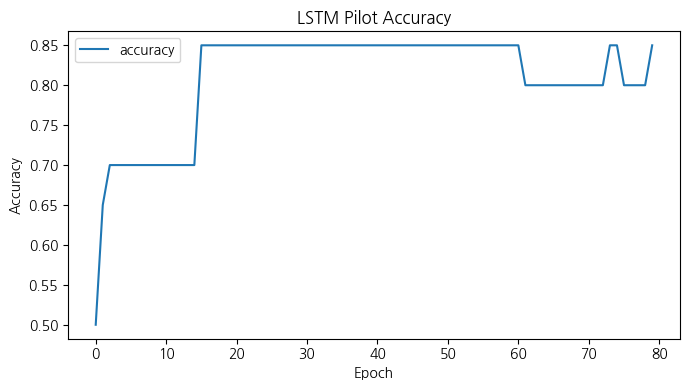

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Pilot Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("figures/lstm_training_accuracy_team_data.png", dpi=200)
plt.show()

LSTM 예측 결과 만들기

In [28]:
pred_prob = lstm_model.predict(X_lstm)
pred_num = pred_prob.argmax(axis=1)

lstm_result_df = seq_wide.copy()
lstm_result_df["predicted_step3"] = [num_to_error[n] for n in pred_num]
lstm_result_df["correct"] = lstm_result_df["step3"] == lstm_result_df["predicted_step3"]

display(lstm_result_df.head(10))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


,student_id,step1,step2,step3,predicted_step3,correct
0,S01,Process,Strategy,Micro,Strategy,False
1,S02,Macro,Process,Strategy,Strategy,True
2,S03,Process,Process,Strategy,Strategy,True
3,S04,Strategy,Strategy,Micro,Micro,True
4,S05,Macro,Macro,Process,Strategy,False
5,S06,Macro,Micro,Micro,Micro,True
6,S07,Process,Strategy,Strategy,Strategy,True
7,S08,Macro,Strategy,Strategy,Strategy,True
8,S09,Macro,Macro,Strategy,Strategy,True
9,S10,Process,Strategy,Strategy,Strategy,True


LSTM 정확도 확인하기

In [29]:
lstm_accuracy = lstm_result_df["correct"].mean()

print("LSTM 파일럿 정확도:", lstm_accuracy)

LSTM 파일럿 정확도: 0.85


새 오류 흐름 예측하기

In [30]:
new_sequence = pd.DataFrame([
    {
        "step1": "Process",
        "step2": "Strategy"
    }
])

new_X = new_sequence.map(lambda x: error_to_num[x]).values

new_pred_prob = lstm_model.predict(new_X)
new_pred_num = new_pred_prob.argmax(axis=1)[0]
new_pred_error = num_to_error[new_pred_num]

print("입력 오류 흐름: Process → Strategy")
print("예측된 다음 오류 유형:", new_pred_error)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
입력 오류 흐름: Process → Strategy
예측된 다음 오류 유형: Strategy


LSTM 결과 저장하기

In [31]:
lstm_result_df.to_csv(
    "data/lstm_result_with_team_data.csv",
    index=False,
    encoding="utf-8-sig"
)

lstm_model.save("models/lstm_error_sequence_team_data.keras")

print("저장 완료:")
print("data/lstm_result_with_team_data.csv")
print("figures/lstm_training_accuracy_team_data.png")
print("models/lstm_error_sequence_team_data.keras")

저장 완료:
data/lstm_result_with_team_data.csv
figures/lstm_training_accuracy_team_data.png
models/lstm_error_sequence_team_data.keras


# Manim 시각화 연결 데이터 만들기

In [32]:
error_explain = {
    "Macro": {
        "korean_name": "개념 이해 오류",
        "simple_explanation": "공식이나 개념의 의미를 정확히 이해하지 못한 경우",
        "visual_plan": "개념의 의미를 그림과 예시로 다시 설명하는 장면"
    },
    "Micro": {
        "korean_name": "계산 과정 오류",
        "simple_explanation": "부호, 계산, 식 정리 과정에서 실수한 경우",
        "visual_plan": "계산 과정에서 실수하기 쉬운 부분을 강조하는 장면"
    },
    "Process": {
        "korean_name": "문제 접근 오류",
        "simple_explanation": "문제를 보고 무엇부터 시작해야 할지 모르는 경우",
        "visual_plan": "문제 조건을 읽고 풀이 순서를 잡는 장면"
    },
    "Strategy": {
        "korean_name": "풀이 전략 선택 오류",
        "simple_explanation": "어떤 공식이나 방법을 사용해야 할지 모르는 경우",
        "visual_plan": "문제 유형에 맞는 풀이 전략을 선택하는 장면"
    }
}

error_explain_df = pd.DataFrame(error_explain).T.reset_index()
error_explain_df = error_explain_df.rename(columns={"index": "error_type"})

error_explain_df.to_csv(
    "data/error_type_explanation.csv",
    index=False,
    encoding="utf-8-sig"
)

display(error_explain_df)

,error_type,korean_name,simple_explanation,visual_plan
0,Macro,개념 이해 오류,공식이나 개념의 의미를 정확히 이해하지 못한 경우,개념의 의미를 그림과 예시로 다시 설명하는 장면
1,Micro,계산 과정 오류,"부호, 계산, 식 정리 과정에서 실수한 경우",계산 과정에서 실수하기 쉬운 부분을 강조하는 장면
2,Process,문제 접근 오류,문제를 보고 무엇부터 시작해야 할지 모르는 경우,문제 조건을 읽고 풀이 순서를 잡는 장면
3,Strategy,풀이 전략 선택 오류,어떤 공식이나 방법을 사용해야 할지 모르는 경우,문제 유형에 맞는 풀이 전략을 선택하는 장면


In [33]:
manim_rows = []

for _, row in lstm_result_df.iterrows():
    student_id = row["student_id"]

    error_flow = [
        row["step1"],
        row["step2"],
        row["step3"],
        row["predicted_step3"]
    ]

    for scene_order, error_type in enumerate(error_flow, start=1):
        info = error_explain[error_type]

        if scene_order == 4:
            scene_role = "예측된 다음 오류"
        else:
            scene_role = f"{scene_order}단계 실제 오류"

        manim_rows.append({
            "student_id": student_id,
            "scene_order": scene_order,
            "scene_role": scene_role,
            "error_type": error_type,
            "korean_name": info["korean_name"],
            "simple_explanation": info["simple_explanation"],
            "visual_plan": info["visual_plan"]
        })

manim_scene_df = pd.DataFrame(manim_rows)

manim_scene_df.to_csv(
    "data/manim_scene_data.csv",
    index=False,
    encoding="utf-8-sig"
)

display(manim_scene_df.head(12))

,student_id,scene_order,scene_role,error_type,korean_name,simple_explanation,visual_plan
0,S01,1,1단계 실제 오류,Process,문제 접근 오류,문제를 보고 무엇부터 시작해야 할지 모르는 경우,문제 조건을 읽고 풀이 순서를 잡는 장면
1,S01,2,2단계 실제 오류,Strategy,풀이 전략 선택 오류,어떤 공식이나 방법을 사용해야 할지 모르는 경우,문제 유형에 맞는 풀이 전략을 선택하는 장면
2,S01,3,3단계 실제 오류,Micro,계산 과정 오류,"부호, 계산, 식 정리 과정에서 실수한 경우",계산 과정에서 실수하기 쉬운 부분을 강조하는 장면
3,S01,4,예측된 다음 오류,Strategy,풀이 전략 선택 오류,어떤 공식이나 방법을 사용해야 할지 모르는 경우,문제 유형에 맞는 풀이 전략을 선택하는 장면
4,S02,1,1단계 실제 오류,Macro,개념 이해 오류,공식이나 개념의 의미를 정확히 이해하지 못한 경우,개념의 의미를 그림과 예시로 다시 설명하는 장면
5,S02,2,2단계 실제 오류,Process,문제 접근 오류,문제를 보고 무엇부터 시작해야 할지 모르는 경우,문제 조건을 읽고 풀이 순서를 잡는 장면
6,S02,3,3단계 실제 오류,Strategy,풀이 전략 선택 오류,어떤 공식이나 방법을 사용해야 할지 모르는 경우,문제 유형에 맞는 풀이 전략을 선택하는 장면
7,S02,4,예측된 다음 오류,Strategy,풀이 전략 선택 오류,어떤 공식이나 방법을 사용해야 할지 모르는 경우,문제 유형에 맞는 풀이 전략을 선택하는 장면
8,S03,1,1단계 실제 오류,Process,문제 접근 오류,문제를 보고 무엇부터 시작해야 할지 모르는 경우,문제 조건을 읽고 풀이 순서를 잡는 장면
9,S03,2,2단계 실제 오류,Process,문제 접근 오류,문제를 보고 무엇부터 시작해야 할지 모르는 경우,문제 조건을 읽고 풀이 순서를 잡는 장면


In [34]:
script_rows = []

for student_id in manim_scene_df["student_id"].unique():
    temp = manim_scene_df[manim_scene_df["student_id"] == student_id]

    actual_flow = temp[temp["scene_order"] <= 3]["korean_name"].tolist()
    predicted_error = temp[temp["scene_order"] == 4]["korean_name"].iloc[0]

    flow_text = " → ".join(actual_flow)

    script = (
        f"{student_id} 학생의 오류 흐름은 {flow_text} 순서로 나타났다. "
        f"LSTM 파일럿 모델은 다음 단계에서 {predicted_error}가 이어질 가능성을 제시하였다. "
        f"따라서 이 학생에게는 오류 흐름에 맞춘 단계별 복습 자료와 시각화 설명이 필요하다."
    )

    script_rows.append({
        "student_id": student_id,
        "actual_error_flow": flow_text,
        "predicted_error": predicted_error,
        "script": script
    })

manim_script_df = pd.DataFrame(script_rows)

manim_script_df.to_csv(
    "data/manim_script_data.csv",
    index=False,
    encoding="utf-8-sig"
)

display(manim_script_df.head())

,student_id,actual_error_flow,predicted_error,script
0,S01,문제 접근 오류 → 풀이 전략 선택 오류 → 계산 과정 오류,풀이 전략 선택 오류,S01 학생의 오류 흐름은 문제 접근 오류 → 풀이 전략 선택 오류 → 계산 과정 ...
1,S02,개념 이해 오류 → 문제 접근 오류 → 풀이 전략 선택 오류,풀이 전략 선택 오류,S02 학생의 오류 흐름은 개념 이해 오류 → 문제 접근 오류 → 풀이 전략 선택 ...
2,S03,문제 접근 오류 → 문제 접근 오류 → 풀이 전략 선택 오류,풀이 전략 선택 오류,S03 학생의 오류 흐름은 문제 접근 오류 → 문제 접근 오류 → 풀이 전략 선택 ...
3,S04,풀이 전략 선택 오류 → 풀이 전략 선택 오류 → 계산 과정 오류,계산 과정 오류,S04 학생의 오류 흐름은 풀이 전략 선택 오류 → 풀이 전략 선택 오류 → 계산 ...
4,S05,개념 이해 오류 → 개념 이해 오류 → 문제 접근 오류,풀이 전략 선택 오류,S05 학생의 오류 흐름은 개념 이해 오류 → 개념 이해 오류 → 문제 접근 오류 ...


In [35]:
function_students = profile_df[profile_df["weak_topic"] == "함수"]["student_id"].tolist()

function_manim_df = manim_scene_df[
    manim_scene_df["student_id"].isin(function_students)
]

function_manim_df.to_csv(
    "data/function_manim_scene_data.csv",
    index=False,
    encoding="utf-8-sig"
)

print("함수 단원 학생 수:", len(function_students))
display(function_manim_df.head(12))

함수 단원 학생 수: 12


,student_id,scene_order,scene_role,error_type,korean_name,simple_explanation,visual_plan
0,S01,1,1단계 실제 오류,Process,문제 접근 오류,문제를 보고 무엇부터 시작해야 할지 모르는 경우,문제 조건을 읽고 풀이 순서를 잡는 장면
1,S01,2,2단계 실제 오류,Strategy,풀이 전략 선택 오류,어떤 공식이나 방법을 사용해야 할지 모르는 경우,문제 유형에 맞는 풀이 전략을 선택하는 장면
2,S01,3,3단계 실제 오류,Micro,계산 과정 오류,"부호, 계산, 식 정리 과정에서 실수한 경우",계산 과정에서 실수하기 쉬운 부분을 강조하는 장면
3,S01,4,예측된 다음 오류,Strategy,풀이 전략 선택 오류,어떤 공식이나 방법을 사용해야 할지 모르는 경우,문제 유형에 맞는 풀이 전략을 선택하는 장면
4,S02,1,1단계 실제 오류,Macro,개념 이해 오류,공식이나 개념의 의미를 정확히 이해하지 못한 경우,개념의 의미를 그림과 예시로 다시 설명하는 장면
5,S02,2,2단계 실제 오류,Process,문제 접근 오류,문제를 보고 무엇부터 시작해야 할지 모르는 경우,문제 조건을 읽고 풀이 순서를 잡는 장면
6,S02,3,3단계 실제 오류,Strategy,풀이 전략 선택 오류,어떤 공식이나 방법을 사용해야 할지 모르는 경우,문제 유형에 맞는 풀이 전략을 선택하는 장면
7,S02,4,예측된 다음 오류,Strategy,풀이 전략 선택 오류,어떤 공식이나 방법을 사용해야 할지 모르는 경우,문제 유형에 맞는 풀이 전략을 선택하는 장면
8,S03,1,1단계 실제 오류,Process,문제 접근 오류,문제를 보고 무엇부터 시작해야 할지 모르는 경우,문제 조건을 읽고 풀이 순서를 잡는 장면
9,S03,2,2단계 실제 오류,Process,문제 접근 오류,문제를 보고 무엇부터 시작해야 할지 모르는 경우,문제 조건을 읽고 풀이 순서를 잡는 장면
